# import libraries

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image
import os
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import LSTM,  Dropout,GlobalAveragePooling2D,Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Sequential
from sklearn.metrics import confusion_matrix, roc_curve, auc
import random
import json

# Image Read and preprocessing


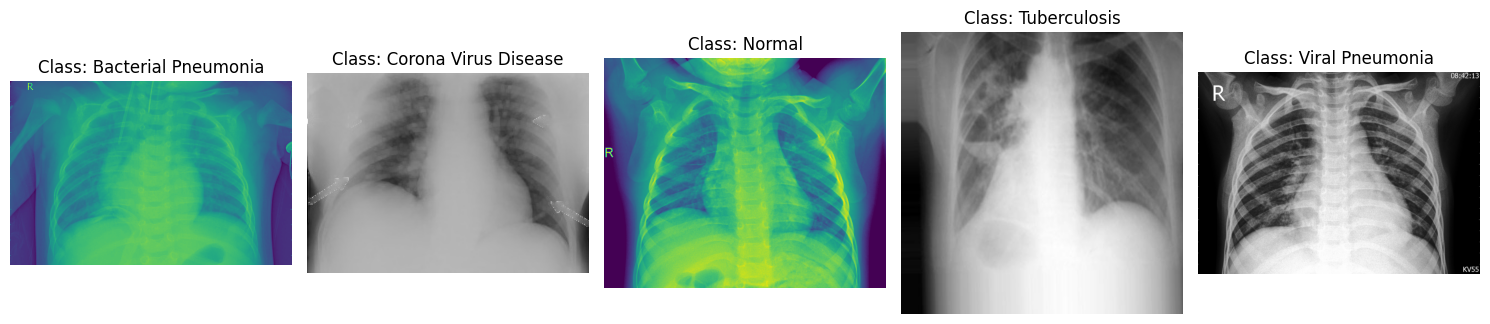

In [ ]:
base_dir = r"\Data\archive\Lung Disease Dataset\train"

# List all class directories (subdirectories in the train folder)
class_dirs = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]

# Number of classes
num_classes = len(class_dirs)

# Create subplots to display one image per class
plt.figure(figsize=(15, 5))

for i, class_dir in enumerate(class_dirs):
    # Get the full path to the class directory
    class_path = os.path.join(base_dir, class_dir)
    
    # Get all images in the class directory
    images = os.listdir(class_path)
    
    # Randomly select one image
    image_name = random.choice(images)
    image_path = os.path.join(class_path, image_name)
    
    # Open the image
    img = Image.open(image_path)
    
    # Plot the image in the corresponding subplot
    plt.subplot(1, num_classes, i + 1)
    plt.imshow(img)
    plt.title(f"Class: {class_dir}")
    plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:


# directories
base_dir = r"\Data\archive\Lung Disease Dataset"
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')


image_size = (224, 224)
batch_size = 32
# image data generators
train_datagen = ImageDataGenerator(rescale=1.0/255)
val_datagen = ImageDataGenerator(rescale=1.0/255)
test_datagen = ImageDataGenerator(rescale=1.0/255)

# Flow from directory for train, val, and test
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,  # Resize images to 224x224
    batch_size=batch_size,
    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# Confirm class mapping
print("Class Indices (Mapping):", train_data.class_indices)


Found 6054 images belonging to 5 classes.
Found 2016 images belonging to 5 classes.
Found 2025 images belonging to 5 classes.
Class Indices (Mapping): {'Bacterial Pneumonia': 0, 'Corona Virus Disease': 1, 'Normal': 2, 'Tuberculosis': 3, 'Viral Pneumonia': 4}


# Build CNN Model 

In [7]:
# Build the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.6),
    Dense(5, activation='softmax')  # Adjust the output units based on the number of classes
])


c:\Users\aymna\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
# compile model
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

c:\Users\aymna\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
190/190 ━━━━━━━━━━━━━━━━━━━━ 380s 2s/step - accuracy: 0.4745 - loss: 1.2993 - val_accuracy: 0.7183 - val_loss: 0.7208
Epoch 2/15
190/190 ━━━━━━━━━━━━━━━━━━━━ 301s 2s/step - accuracy: 0.7160 - loss: 0.7236 - val_accuracy: 0.7674 - val_loss: 0.5861
Epoch 3/15
190/190 ━━━━━━━━━━━━━━━━━━━━ 302s 2s/step - accuracy: 0.7506 - loss: 0.6251 - val_accuracy: 0.7827 - val_loss: 0.5017
Epoch 4/15
190/190 ━━━━━━━━━━━━━━━━━━━━ 304s 2s/step - accuracy: 0.7886 - loss: 0.5109 - val_accuracy: 0.7902 - val_loss: 0.4937
Epoch 5/15
190/190 ━━━━━━━━━━━━━━━━━━━━ 305s 2s/step - accuracy: 0.8026 - loss: 0.4942 - val_accuracy: 0.7946 - val_loss: 0.4771
Epoch 6/15
190/190 ━━━━━━━━━━━━━━━━━━━━ 312s 2s/step - accuracy: 0.8078 - loss: 0.4885 - val_accuracy: 0.8011 - val_loss: 0.4738
Epoch 7/15
190/190 ━━━━━━━━━━━━━━━━━━━━ 288s 2s/step - accuracy: 0.8390 - loss: 0.3903 - val_accuracy: 0.7961 - val_loss: 0.4950
Epoch 8/15
190/190 ━━━━━━━━━━━━━━━━━━━━ 286s 2s/step - accuracy: 0.8400 - loss: 0.3887 - val_accu

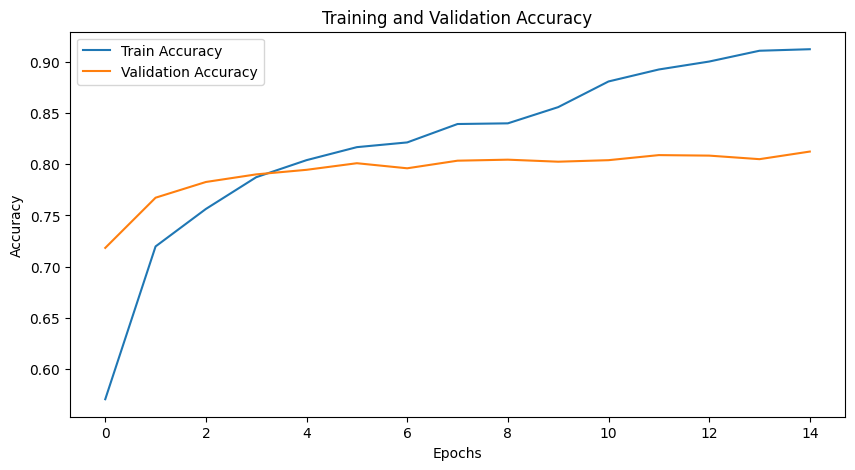

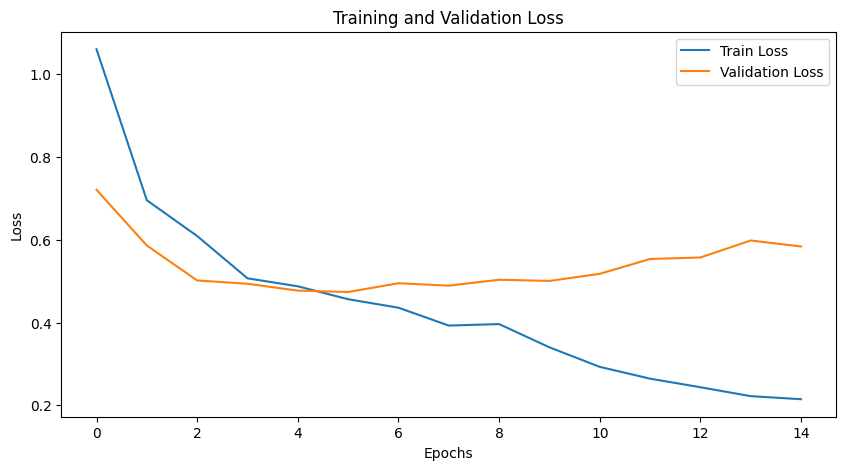

AttributeError: 'list' object has no attribute 'history'

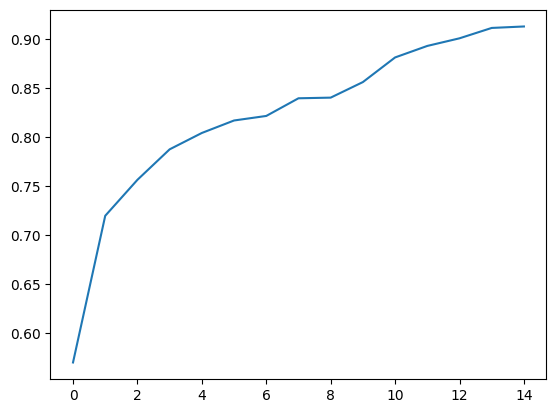

In [9]:
# Train the model
Training = model.fit(train_data,validation_data=val_data,epochs=15,verbose=1)
train_accuracy = Training.history['accuracy']
val_accuracy = Training.history['val_accuracy']
train_loss = Training.history['loss']
val_loss = Training.history['val_loss']

# Plot training and validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(train_accuracy, label='Train Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()





from tensorflow.keras.models import load_model
model.save("my_cnn_model.h5")
model = load_model("my_cnn_model.h5")


In [5]:
from tensorflow.keras.models import load_model

model = load_model("my_cnn_model.h5")
